In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from lightgbm import LGBMClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)
from sklearn.utils.class_weight import compute_class_weight

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping
plt.style.use("default")


### Loading Data

In [ ]:
file_path = "HTRU_2.csv"

column_names = [
    "mean_ip",
    "std_ip",
    "skewness_ip",
    "kurtosis_ip",
    "mean_dm_snr",
    "std_dm_snr",
    "skewness_dm_snr",
    "kurtosis_dm_snr",
    "target",
]

df = pd.read_csv(file_path, header=None, names=column_names)

X = df.drop(columns="target")
y = df["target"]

# splitting train/test

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
classes = np.unique(y_train)

###  Class Imbalance Handling

In [ ]:
# class weights
classes = np.unique(y_train)
weights = compute_class_weight("balanced", classes=classes, y=y_train)
class_weights = dict(zip(classes, weights))

# for boosting models (XGBoost / LightGBM)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

###Models Explorations


In [ ]:
# Logistic Regression (baseline)
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train, y_train)

# Random Forest
rf = RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=42)
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)
xgb.fit(X_train, y_train)

# LightGBM
lgbm = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42
)
lgbm.fit(X_train, y_train)


[LightGBM] [Info] Number of positive: 1311, number of negative: 13007
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003499 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2040
[LightGBM] [Info] Number of data points in the train set: 14318, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.091563 -> initscore=-2.294697
[LightGBM] [Info] Start training from score -2.294697


LGBMClassifier(n_estimators=300, random_state=42,
               scale_pos_weight=np.float64(9.921434019832189))

**MLP**

In [ ]:
# normalizing inputs for MLP
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# MLP model design
mlp = Sequential([
    Input(shape=(X_train_s.shape[1],)),
    Dense(32, activation="relu"),
    Dropout(0.2),
    Dense(16, activation="relu"),
    Dropout(0.2),
    Dense(1, activation="sigmoid")
])

mlp.compile(optimizer="adam", loss="binary_crossentropy")

mlp.fit(
    X_train_s,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    class_weight=class_weights,
    verbose=0
)

### Hyperparameters Turning

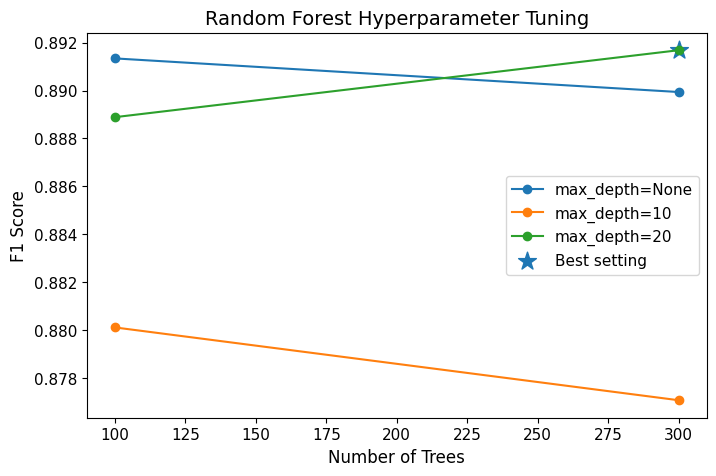

In [ ]:
# Random Forest
rf_rows = []
best_rf = None
best_rf_params = None
best_rf_f1 = -1

for n in [100, 300]:
    for depth in [None, 10, 20]:
        model = RandomForestClassifier(
            n_estimators=n,
            max_depth=depth,
            class_weight="balanced",
            random_state=42
        )
        model.fit(X_train, y_train)

        prob = model.predict_proba(X_test)[:, 1]
        pred = (prob >= 0.5).astype(int)

        f1 = f1_score(y_test, pred)
        roc = roc_auc_score(y_test, prob)

        rf_rows.append({
            "n_estimators": n,
            "max_depth": "None" if depth is None else depth,
            "F1": f1,
            "ROC_AUC": roc
        })

        if f1 > best_rf_f1:
            best_rf_f1 = f1
            best_rf = model
            best_rf_params = {"n_estimators": n, "max_depth": depth}

rf_tuning_df = pd.DataFrame(rf_rows)

# plot
plt.figure(figsize=(8, 5))

for depth in rf_tuning_df["max_depth"].unique():
    subset = rf_tuning_df[rf_tuning_df["max_depth"] == depth].sort_values("n_estimators")
    plt.plot(
        subset["n_estimators"],
        subset["F1"],
        marker="o",
        label=f"max_depth={depth}"
    )

best_row = rf_tuning_df.loc[rf_tuning_df["F1"].idxmax()]
plt.scatter(
    best_row["n_estimators"],
    best_row["F1"],
    marker="*",
    s=180,
    label="Best setting"
)

plt.title("Random Forest Hyperparameter Tuning")
plt.xlabel("Number of Trees")
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
rf_tuning_df

,n_estimators,max_depth,F1,ROC_AUC
0,100,None,0.891339,0.961699
1,100,10,0.880121,0.975829
2,100,20,0.888889,0.963491
3,300,None,0.889937,0.968342
4,300,10,0.877086,0.977417
5,300,20,0.891680,0.968649


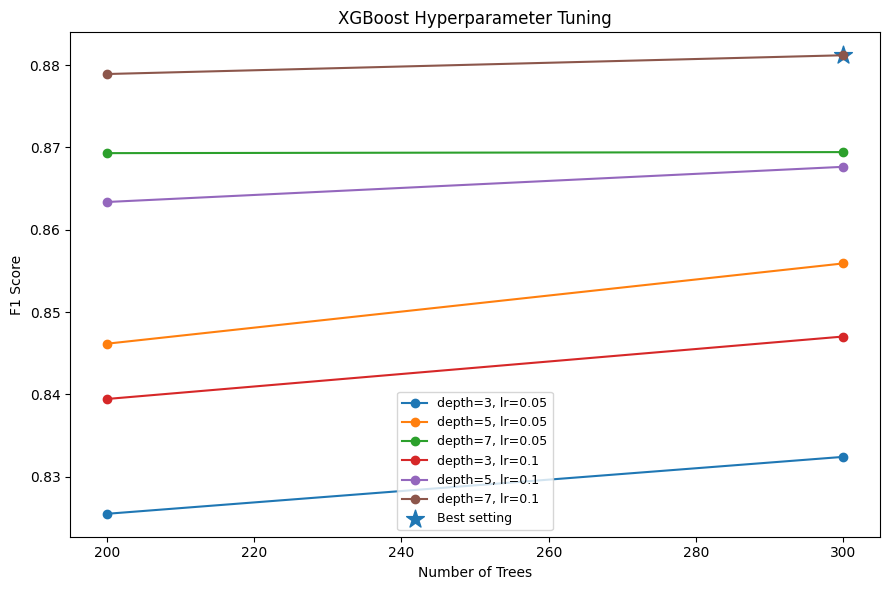

In [ ]:
# XGBoost
xgb_rows = []
best_xgb = None
best_xgb_params = None
best_xgb_f1 = -1

for n in [200, 300]:
    for depth in [3, 5, 7]:
        for lr in [0.05, 0.1]:
            model = XGBClassifier(
                n_estimators=n,
                max_depth=depth,
                learning_rate=lr,
                scale_pos_weight=scale_pos_weight,
                eval_metric="logloss",
                random_state=42
            )
            model.fit(X_train, y_train)

            prob = model.predict_proba(X_test)[:, 1]
            pred = (prob >= 0.5).astype(int)

            f1 = f1_score(y_test, pred)
            roc = roc_auc_score(y_test, prob)

            xgb_rows.append({
                "n_estimators": n,
                "max_depth": depth,
                "learning_rate": lr,
                "F1": f1,
                "ROC_AUC": roc
            })

            if f1 > best_xgb_f1:
                best_xgb_f1 = f1
                best_xgb = model
                best_xgb_params = {
                    "n_estimators": n,
                    "max_depth": depth,
                    "learning_rate": lr
                }

xgb_tuning_df = pd.DataFrame(xgb_rows)

# plot for hyperparameters tuning
plt.figure(figsize=(9, 6))

for lr in sorted(xgb_tuning_df["learning_rate"].unique()):
    for depth in sorted(xgb_tuning_df["max_depth"].unique()):
        subset = xgb_tuning_df[
            (xgb_tuning_df["learning_rate"] == lr) &
            (xgb_tuning_df["max_depth"] == depth)
        ].sort_values("n_estimators")

        plt.plot(
            subset["n_estimators"],
            subset["F1"],
            marker="o",
            label=f"depth={depth}, lr={lr}"
        )

best_row = xgb_tuning_df.loc[xgb_tuning_df["F1"].idxmax()]
plt.scatter(
    best_row["n_estimators"],
    best_row["F1"],
    marker="*",
    s=180,
    label="Best setting"
)

plt.title("XGBoost Hyperparameter Tuning")
plt.xlabel("Number of Trees")
plt.ylabel("F1 Score")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
xgb_tuning_df

,n_estimators,max_depth,learning_rate,F1,ROC_AUC
0,200,3,0.05,0.825485,0.977520
1,200,3,0.10,0.839437,0.973031
2,200,5,0.05,0.846154,0.972976
3,200,5,0.10,0.863372,0.971528
4,200,7,0.05,0.869310,0.974678
5,200,7,0.10,0.878924,0.974838
6,300,3,0.05,0.832402,0.976026
7,300,3,0.10,0.847025,0.971904
8,300,5,0.05,0.855908,0.973474
9,300,5,0.10,0.867647,0.971652


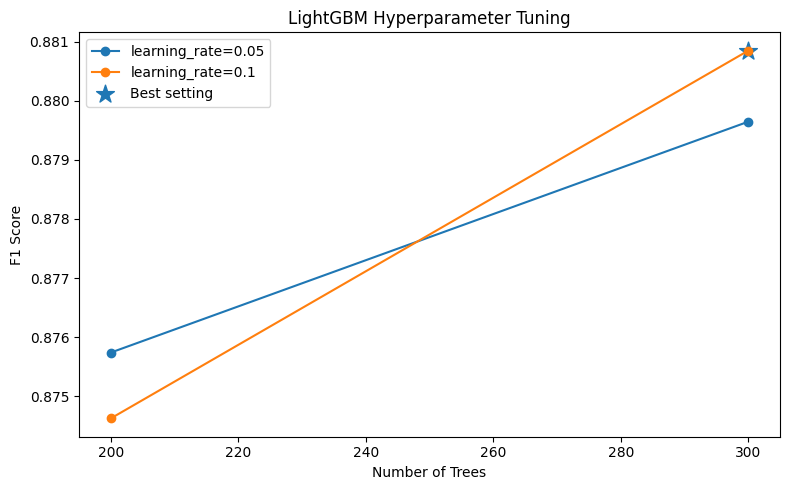

In [ ]:
# LightGBM
lgbm_rows = []
best_lgbm = None
best_lgbm_params = None
best_lgbm_f1 = -1

for n in [200, 300]:
    for lr in [0.05, 0.1]:
        model = LGBMClassifier(
            n_estimators=n,
            learning_rate=lr,
            scale_pos_weight=scale_pos_weight,
            random_state=42,
            verbosity=-1
        )
        model.fit(X_train, y_train)

        prob = model.predict_proba(X_test)[:, 1]
        pred = (prob >= 0.5).astype(int)

        f1 = f1_score(y_test, pred)
        roc = roc_auc_score(y_test, prob)

        lgbm_rows.append({
            "n_estimators": n,
            "learning_rate": lr,
            "F1": f1,
            "ROC_AUC": roc
        })

        if f1 > best_lgbm_f1:
            best_lgbm_f1 = f1
            best_lgbm = model
            best_lgbm_params = {
                "n_estimators": n,
                "learning_rate": lr
            }

lgbm_tuning_df = pd.DataFrame(lgbm_rows)

# plot
plt.figure(figsize=(8, 5))

for lr in sorted(lgbm_tuning_df["learning_rate"].unique()):
    subset = lgbm_tuning_df[lgbm_tuning_df["learning_rate"] == lr].sort_values("n_estimators")
    plt.plot(
        subset["n_estimators"],
        subset["F1"],
        marker="o",
        label=f"learning_rate={lr}"
    )

best_row = lgbm_tuning_df.loc[lgbm_tuning_df["F1"].idxmax()]
plt.scatter(
    best_row["n_estimators"],
    best_row["F1"],
    marker="*",
    s=180,
    label="Best setting"
)

plt.title("LightGBM Hyperparameter Tuning")
plt.xlabel("Number of Trees")
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

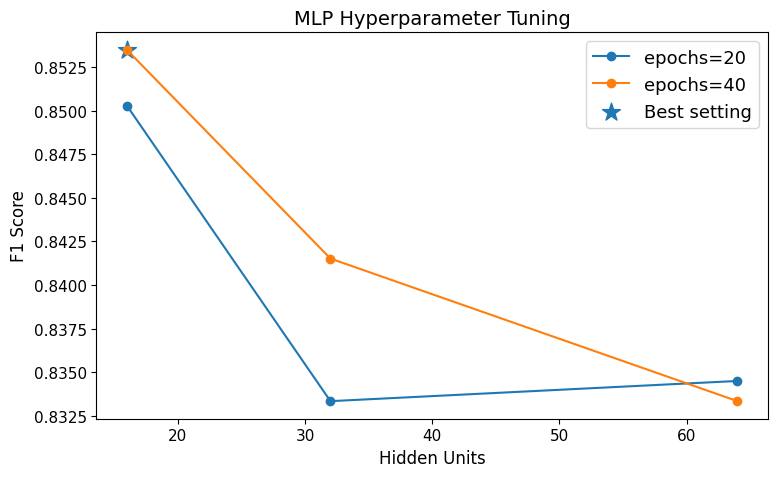

In [ ]:
# MLP
mlp_rows = []
best_mlp = None
best_mlp_params = None
best_mlp_f1 = -1

for units in [16, 32, 64]:
    for epochs in [20, 40]:
        model = Sequential([
            Input(shape=(X_train_s.shape[1],)),
            Dense(units, activation="relu"),
            Dropout(0.2),
            Dense(units // 2, activation="relu"),
            Dropout(0.2),
            Dense(1, activation="sigmoid")
        ])

        model.compile(
            optimizer="adam",
            loss="binary_crossentropy"
        )

        model.fit(
            X_train_s,
            y_train,
            epochs=epochs,
            batch_size=32,
            class_weight=class_weights,
            verbose=0
        )

        prob = model.predict(X_test_s, verbose=0).ravel()
        pred = (prob >= 0.5).astype(int)

        f1 = f1_score(y_test, pred)
        roc = roc_auc_score(y_test, prob)

        mlp_rows.append({
            "units": units,
            "epochs": epochs,
            "F1": f1,
            "ROC_AUC": roc
        })

        if f1 > best_mlp_f1:
            best_mlp_f1 = f1
            best_mlp = model
            best_mlp_params = {
                "units": units,
                "epochs": epochs
            }

mlp_tuning_df = pd.DataFrame(mlp_rows)

# Plot
plt.figure(figsize=(8, 5))

for epochs in sorted(mlp_tuning_df["epochs"].unique()):
    subset = mlp_tuning_df[mlp_tuning_df["epochs"] == epochs].sort_values("units")
    plt.plot(
        subset["units"],
        subset["F1"],
        marker="o",
        label=f"epochs={epochs}"
    )

best_row = mlp_tuning_df.loc[mlp_tuning_df["F1"].idxmax()]
plt.scatter(
    best_row["units"],
    best_row["F1"],
    marker="*",
    s=180,
    label="Best setting"
)
plt.title("MLP Hyperparameter Tuning")
plt.xlabel("Hidden Units")
plt.ylabel("F1 Score")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
mlp_tuning_df

,units,epochs,F1,ROC_AUC
0,16,20,0.844320,0.978754
1,16,40,0.811321,0.975141
2,32,20,0.844320,0.977318
3,32,40,0.862069,0.977245
4,64,20,0.832178,0.976184
5,64,40,0.865801,0.977546


In [ ]:
# LR (baseline)
logreg = LogisticRegression(max_iter=1000, class_weight="balanced")
logreg.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

## Evaluation

In [ ]:
# evaluation
def eval_model(name, y_true, y_pred, y_prob):
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_prob)
    }


In [ ]:
final_results = []

# Logistic Regression
logreg_prob = logreg.predict_proba(X_test)[:, 1]
logreg_pred = (logreg_prob >= 0.5).astype(int)
final_results.append(eval_model("LogReg", y_test, logreg_pred, logreg_prob))

# Random Forest
rf_prob = best_rf.predict_proba(X_test)[:, 1]
rf_pred = (rf_prob >= 0.5).astype(int)
final_results.append(eval_model("RF", y_test, rf_pred, rf_prob))

# XGBoost
xgb_prob = best_xgb.predict_proba(X_test)[:, 1]
xgb_pred = (xgb_prob >= 0.5).astype(int)
final_results.append(eval_model("XGB", y_test, xgb_pred, xgb_prob))

# LightGBM
lgbm_prob = best_lgbm.predict_proba(X_test)[:, 1]
lgbm_pred = (lgbm_prob >= 0.5).astype(int)
final_results.append(eval_model("LGBM", y_test, lgbm_pred, lgbm_prob))

# MLP
mlp_prob = best_mlp.predict(X_test_s, verbose=0).ravel()
mlp_pred = (mlp_prob >= 0.5).astype(int)
final_results.append(eval_model("MLP", y_test, mlp_pred, mlp_prob))

# Final results table
final_results_df = pd.DataFrame(final_results).sort_values(by="F1", ascending=False).reset_index(drop=True)

print("\nComparison for the best version of each model:")
print(final_results_df.round(4))


Comparison for the best version of each model:
    Model  Accuracy  Precision  Recall      F1  ROC_AUC
0      RF    0.9807     0.9191  0.8659  0.8917   0.9686
1     XGB    0.9779     0.8694  0.8933  0.8812   0.9751
2    LGBM    0.9779     0.8716  0.8902  0.8808   0.9711
3     MLP    0.9740     0.8219  0.9146  0.8658   0.9775
4  LogReg    0.9693     0.7824  0.9207  0.8459   0.9728


## Results

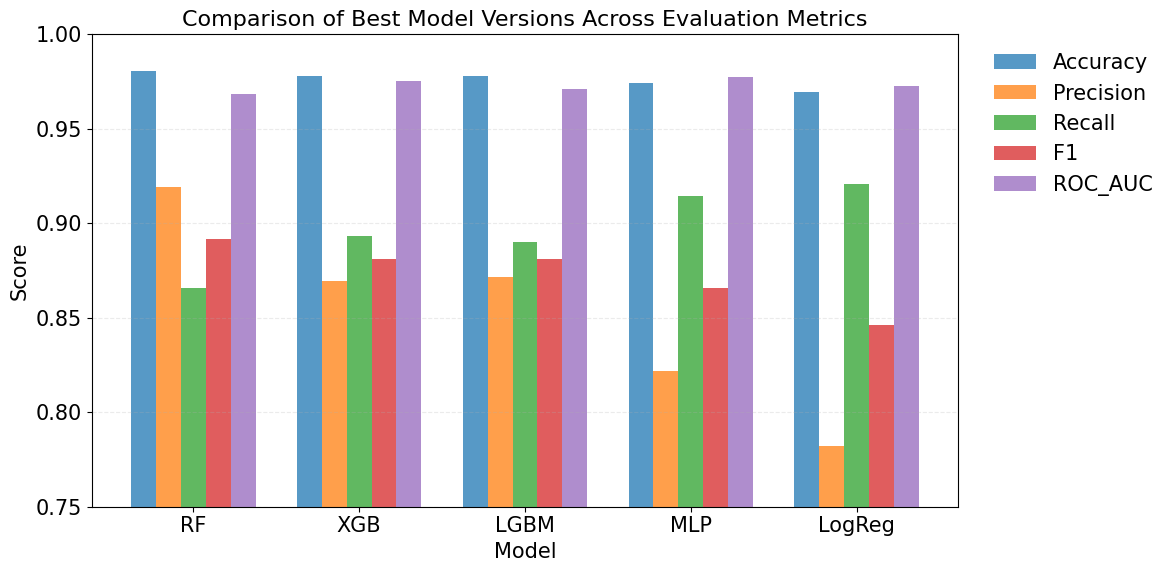

In [ ]:
metrics = ["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]
x = np.arange(len(final_results_df["Model"]))
width = 0.15

plt.figure(figsize=(12, 6))

for i, metric in enumerate(metrics):
    plt.bar(
        x + i * width,
        final_results_df[metric],
        width=width,
        label=metric,
        alpha=0.75
    )

plt.xticks(x + width * 2, final_results_df["Model"])
plt.ylim(0.75, 1.0)
plt.xlabel("Model")
plt.ylabel("Score")
plt.title("Comparison of Best Model Versions Across Evaluation Metrics")
plt.grid(axis="y", linestyle="--", alpha=0.25)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    frameon=False
)
plt.rcParams.update({
    "font.size": 16,
    "axes.titlesize": 24,
    "axes.labelsize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
    "legend.fontsize": 15
})

plt.tight_layout()
plt.show()

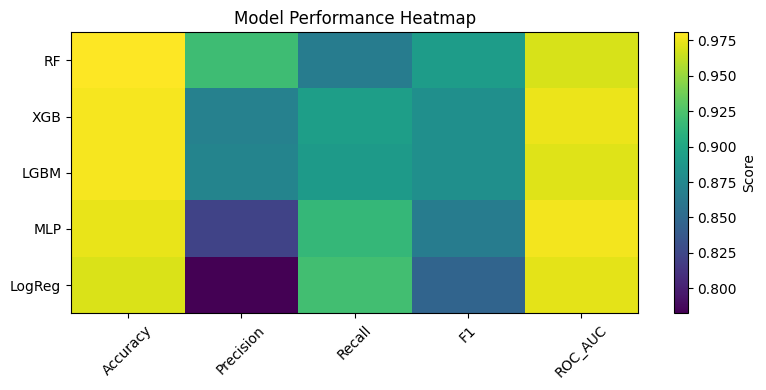

In [ ]:
plot_df = final_results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1", "ROC_AUC"]]

plt.figure(figsize=(8, 4))
plt.imshow(plot_df, aspect="auto")
plt.colorbar(label="Score")
plt.xticks(range(len(plot_df.columns)), plot_df.columns, rotation=45)
plt.yticks(range(len(plot_df.index)), plot_df.index)
plt.title("Model Performance Heatmap")
plt.tight_layout()
plt.show()

In [ ]:
# ranking the models performace by f1

final_results_df["Rank_by_F1"] = final_results_df["F1"].rank(ascending=False, method="min").astype(int)
print(final_results_df.round(4))

    Model  Accuracy  Precision  Recall      F1  ROC_AUC  Rank_by_F1
0      RF    0.9807     0.9191  0.8659  0.8917   0.9686           1
1     XGB    0.9779     0.8694  0.8933  0.8812   0.9751           2
2    LGBM    0.9779     0.8716  0.8902  0.8808   0.9711           3
3     MLP    0.9740     0.8219  0.9146  0.8658   0.9775           4
4  LogReg    0.9693     0.7824  0.9207  0.8459   0.9728           5


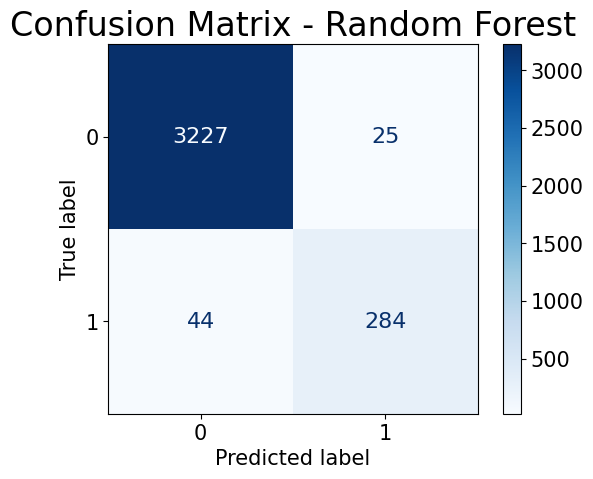

In [50]:
# confusion matrix for best model (Random Forest)
cm = confusion_matrix(y_test, rf_pred)

print("Confusion Matrix (Random Forest):")
print(cm)

# Optional: plot for readability
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [53]:
cms = {
    "RF": confusion_matrix(y_test, rf_pred),
    "LGBM": confusion_matrix(y_test, lgbm_pred),
    "MLP": confusion_matrix(y_test, mlp_pred),
}

# converting for display
rows = []
for name, cm in cms.items():
    tn, fp, fn, tp = cm.ravel()
    rows.append({
        "Model": name,
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp
    })

cm_df = pd.DataFrame(rows).sort_values(by="TP", ascending=False)
print(cm_df)

  Model    TN  FP  FN   TP
2   MLP  3187  65  28  300
1  LGBM  3209  43  36  292
0    RF  3227  25  44  284


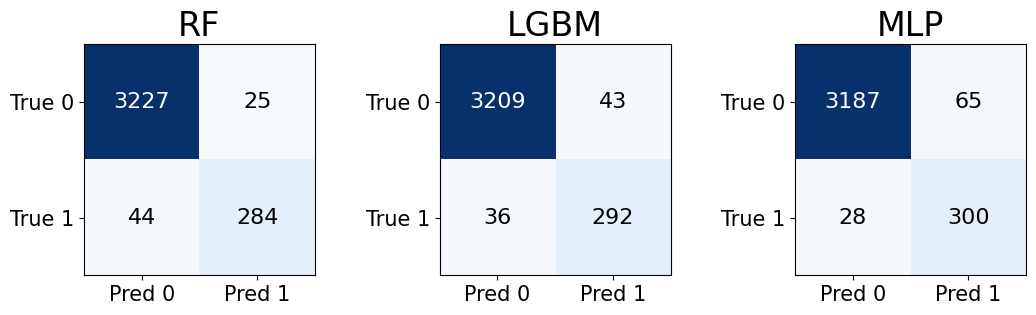

In [52]:
# confusion matrix comparison between best models

models = list(cms.keys())
fig, axes = plt.subplots(1, len(models), figsize=(13, 3))

for ax, model in zip(axes, models):
    cm = cms[model]

    im = ax.imshow(cm, cmap="Blues", vmin=0)
    threshold = cm.max() / 2

    ax.set_title(model)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Pred 0", "Pred 1"])
    ax.set_yticklabels(["True 0", "True 1"])

    for i in range(2):
        for j in range(2):
            color = "white" if cm[i, j] > threshold else "black"
            ax.text(j, i, cm[i, j], ha="center", va="center", color=color)
plt.show()